### Importación de datos



In [54]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,"164,300.00","6,900.00",16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.61,-74.08
1,Mesa de comedor,Muebles,"192,300.00","8,400.00",18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25,-75.56
2,Juego de mesa,Juguetes,"209,600.00","15,900.00",15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.40,-75.51
3,Microondas,Electrodomésticos,"757,500.00","41,000.00",03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.44,-76.52
4,Silla de oficina,Muebles,"335,200.00","20,200.00",07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25,-75.56


In [55]:
tienda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [56]:
tienda.columns

Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')

# Formulas auxiliares

In [77]:
def preparar_datos(tiendas_lista):
    for i, df in enumerate(tiendas_lista, 1):
        df['Tienda'] = f'Tienda {i}'
    return pd.concat(tiendas_lista, ignore_index=True)

def calcular_facturacion(df_total):
    resumen = df_total.groupby('Tienda')['Precio'].sum().reset_index()
    resumen.columns = ['Tienda', 'Facturación Total']
    pd.options.display.float_format = '{:,.2f}'.format
    return resumen

def calcular_ventas_categoria(df_total):
    return df_total.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False).reset_index()

def calcular_rentabilidad_categoria(df_total):
    resumen = df_total.groupby(['Tienda', 'Categoría del Producto'])['Precio'].sum().reset_index()
    resumen = resumen.sort_values('Precio', ascending=False).drop_duplicates('Tienda')
    resumen = resumen.sort_values('Tienda')[['Tienda', 'Categoría del Producto', 'Precio']]
    resumen.columns = ['Tienda', 'Categoría más Rentable', 'Beneficio Total']
    return resumen

def calcular_calificaciones(df_total):
    resumen = df_total.groupby('Tienda')['Calificación'].mean().reset_index()
    resumen.columns = ['Tienda', 'Calificación Promedio']
    return resumen

def calcular_distribucion_estrellas(df_total):
    return df_total.groupby(['Tienda', 'Calificación']).size().unstack(fill_value=0)

def calcular_productos_extremos(df_total):
    conteo = df_total.groupby(['Tienda', 'Producto']).size().reset_index(name='Ventas')
    mas = conteo.sort_values(['Tienda', 'Ventas'], ascending=[True, False]).drop_duplicates('Tienda')
    menos = conteo.sort_values(['Tienda', 'Ventas'], ascending=[True, True]).drop_duplicates('Tienda')

    resumen = pd.merge(mas, menos, on='Tienda', suffixes=(' Mas', ' Menos'))
    resumen['Mas Vendido'] = resumen.apply(lambda x: f"{x['Producto Mas']} ({x['Ventas Mas']} unds)", axis=1)
    resumen['Menos Vendido'] = resumen.apply(lambda x: f"{x['Producto Menos']} ({x['Ventas Menos']} unds)", axis=1)
    return resumen[['Tienda', 'Mas Vendido', 'Menos Vendido']]

def calcular_envio_promedio(df_total):
    resumen = df_total.groupby('Tienda')['Costo de envío'].mean().reset_index()
    resumen.columns = ['Tienda', 'Costo de Envío Promedio']
    return resumen

# Ejecución de las funciones
todas_las_tiendas = preparar_datos([tienda, tienda2, tienda3, tienda4])
facturacion_tiendas = calcular_facturacion(todas_las_tiendas)
ventas_por_categoria = calcular_ventas_categoria(todas_las_tiendas)
resumen_beneficios = calcular_rentabilidad_categoria(todas_las_tiendas)
calificaciones_promedio = calcular_calificaciones(todas_las_tiendas)
distribucion_estrellas = calcular_distribucion_estrellas(todas_las_tiendas)
resumen_extremos = calcular_productos_extremos(todas_las_tiendas)
envio_promedio = calcular_envio_promedio(todas_las_tiendas)

#1. Análisis de facturación



In [58]:
display(facturacion_tiendas)

,Tienda,Facturación Total
0,Tienda 1,"1,150,880,400.00"
1,Tienda 2,"1,116,343,500.00"
2,Tienda 3,"1,098,019,600.00"
3,Tienda 4,"1,038,375,700.00"


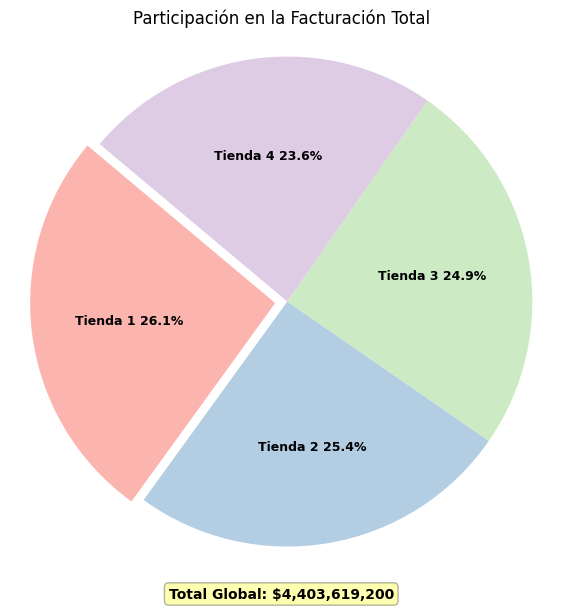

In [93]:
import matplotlib.pyplot as plt

# Datos optimizados
labels_raw = facturacion_tiendas['Tienda']
values = facturacion_tiendas['Facturación Total']
total = values.sum()

# Combinamos etiquetas y porcentajes en una sola lista
labels_final = [f"{n} {(v/total)*100:.1f}%" for n, v in zip(labels_raw, values)]

plt.figure(figsize=(7, 7))
# Quitamos wedgeprops para volver al formato de pastel sólido
plt.pie(values,
        labels=labels_final,
        startangle=140,
        colors=plt.cm.Pastel1.colors,
        explode=(0.05, 0, 0, 0),
        labeldistance=0.6,
        textprops={'fontsize': 9, 'fontweight': 'bold', 'ha': 'center'})

plt.title('Participación en la Facturación Total', fontsize=12)

# Etiqueta de total global
plt.annotate(f'Total Global: ${total:,.0f}',
             xy=(0.5, -0.05), xycoords='axes fraction',
             fontsize=10, fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))

plt.axis('equal')
plt.show()

# 2. Ventas por categoría

In [60]:
# @title Ventas Totales por Categoría

display(ventas_por_categoria)

,Categoría del Producto,Precio
0,Electrónicos,"1,660,576,500.00"
1,Electrodomésticos,"1,324,751,100.00"
2,Muebles,"757,661,000.00"
3,Instrumentos musicales,"348,772,600.00"
4,Deportes y diversión,"142,977,700.00"
5,Juguetes,"73,604,400.00"
6,Artículos para el hogar,"57,579,800.00"
7,Libros,"37,696,100.00"


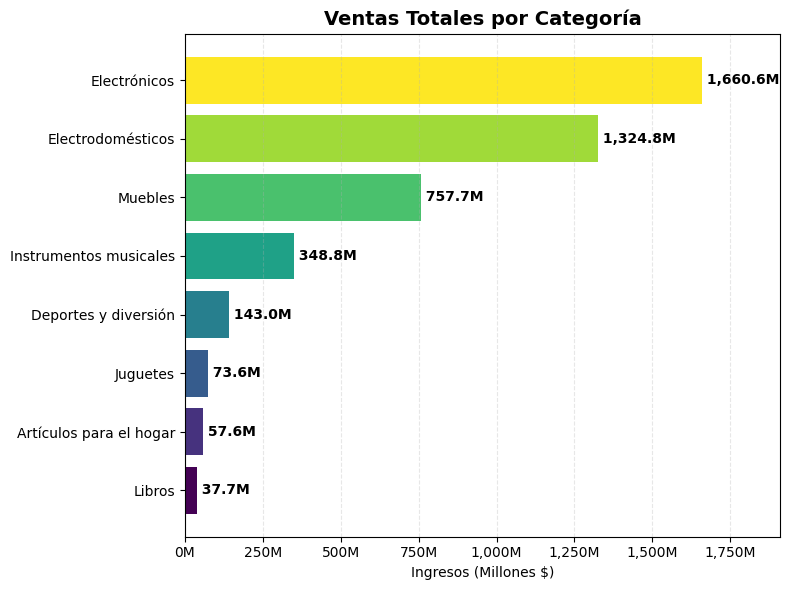

In [95]:
# @title Gráfico: Ventas Totales por Categoría
import matplotlib.ticker as ticker

# Preparamos los datos ordenados
datos = ventas_por_categoria.sort_values('Precio', ascending=True)

plt.figure(figsize=(8, 6))
# Usamos la paleta viridis para mejor visibilidad y contraste
bars = plt.barh(datos['Categoría del Producto'], datos['Precio'],
                color=plt.cm.viridis(np.linspace(0, 1, len(datos))))

plt.title('Ventas Totales por Categoría', fontsize=14, fontweight='bold')
plt.xlabel('Ingresos (Millones $)')

# Añadimos las etiquetas de texto al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f' {width*1e-6:,.1f}M',
             va='center', fontweight='bold', fontsize=10)

# Formateador para el eje X
def millones(x, pos):
    return f'{x*1e-6:,.0f}M'

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(millones))

# Ampliamos un poco el límite del eje X para que quepan las etiquetas
plt.xlim(0, datos['Precio'].max() * 1.15)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Resumen de beneficios

In [62]:
resumen_beneficios

,Tienda,Categoría más Rentable,Beneficio Total
3,Tienda 1,Electrónicos,"429,493,500.00"
11,Tienda 2,Electrónicos,"410,831,100.00"
19,Tienda 3,Electrónicos,"410,775,800.00"
27,Tienda 4,Electrónicos,"409,476,100.00"


# 3. Calificación promedio de la tienda


In [64]:
# @title Calificaciones Promedio por tienda
calificaciones_promedio

,Tienda,Calificación Promedio
0,Tienda 1,3.98
1,Tienda 2,4.04
2,Tienda 3,4.05
3,Tienda 4,4.00


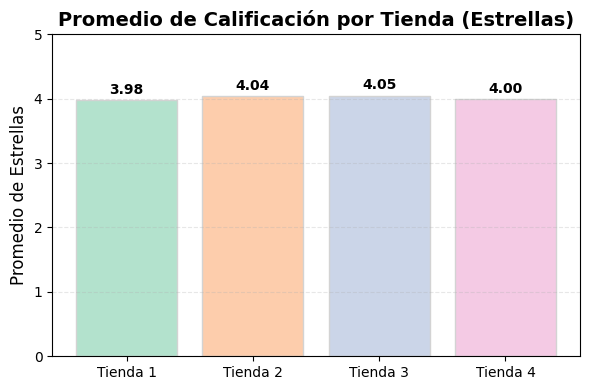

In [96]:
# @title Promedio de Calificación por Tienda

import matplotlib.pyplot as plt

# Datos
tiendas = calificaciones_promedio['Tienda']
promedios = calificaciones_promedio['Calificación Promedio']

plt.figure(figsize=(6, 4))

# Colores pastel
colores = plt.cm.Pastel2.colors

# Gráfico de barras
bars = plt.bar(tiendas, promedios, color=colores,
               edgecolor='lightgray')

# Personalización
plt.title('Promedio de Calificación por Tienda (Estrellas)',
          fontsize=14, fontweight='bold')
plt.ylabel('Promedio de Estrellas', fontsize=12)
plt.ylim(0, 5) # Ajustado para comenzar en 0

# Añadimos etiquetas de valor sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}',
             ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

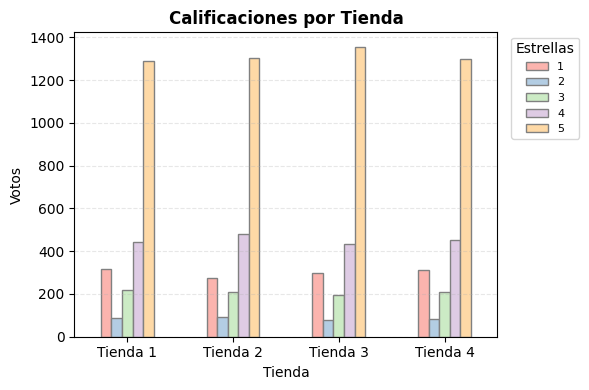

In [71]:
import matplotlib.pyplot as plt

# @title Gráfico: Calificaciones por Tienda
distribucion_estrellas.plot(kind='bar', figsize=(6, 4), color=plt.cm.Pastel1.colors, edgecolor='gray')

plt.title('Calificaciones por Tienda', fontsize=12, fontweight='bold')
plt.xlabel('Tienda', fontsize=10)
plt.ylabel('Votos', fontsize=10)
plt.xticks(rotation=0)
plt.legend(title='Estrellas', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

In [68]:
# @title Productos más y menos vendidos
display(resumen_extremos)

,Tienda,Mas Vendido,Menos Vendido
0,Tienda 1,Armario (60 unds),Auriculares con micrófono (33 unds)
1,Tienda 2,Iniciando en programación (65 unds),Juego de mesa (32 unds)
2,Tienda 3,Kit de bancas (57 unds),Bloques de construcción (35 unds)
3,Tienda 4,Cama box (62 unds),Guitarra eléctrica (33 unds)


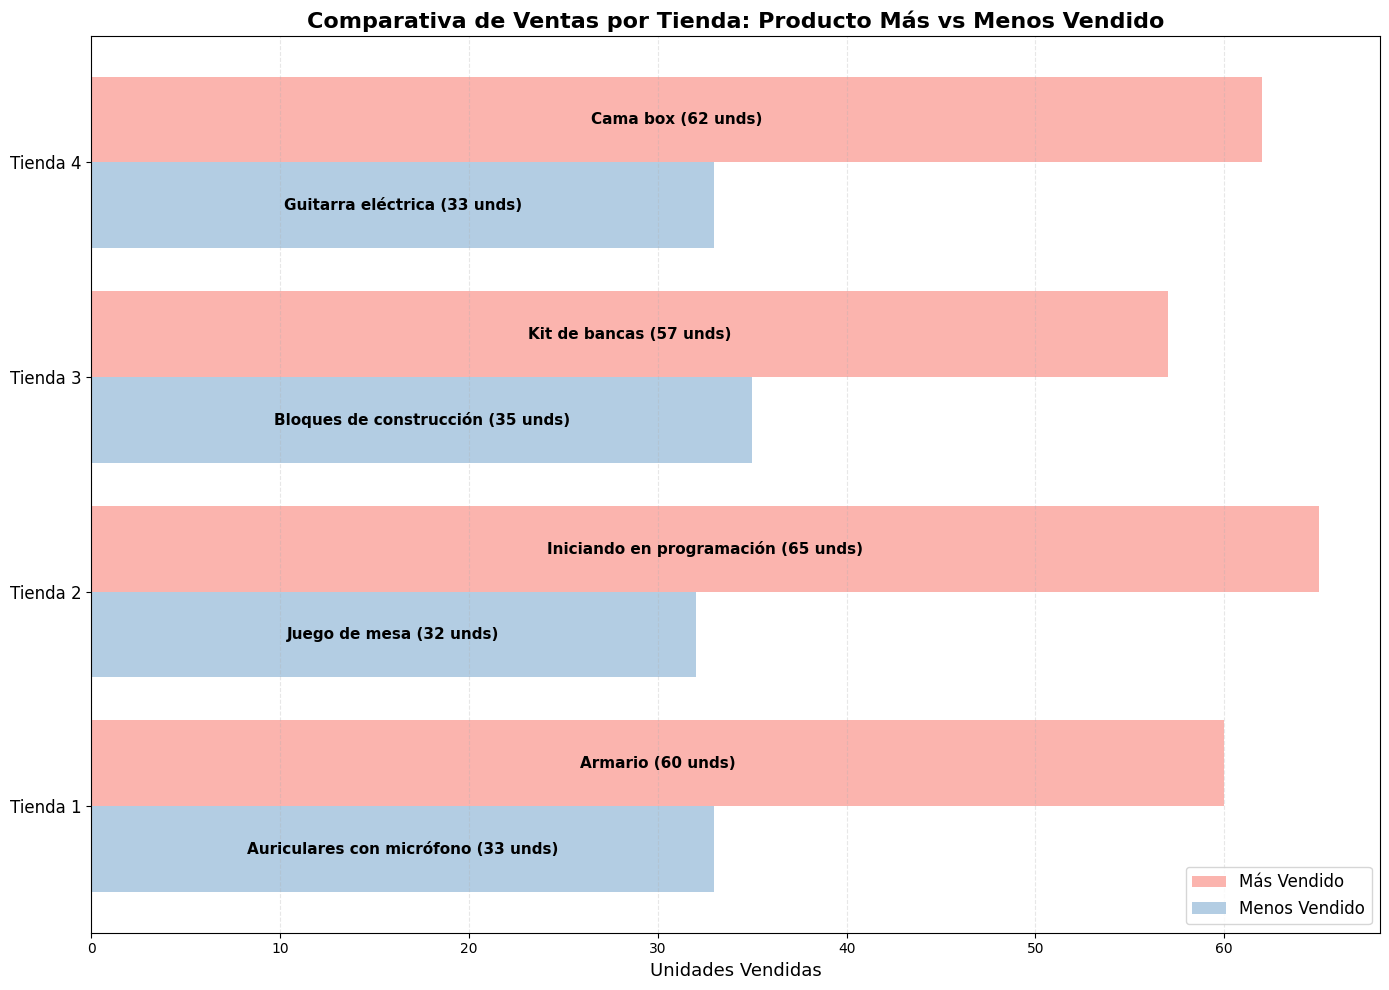

In [ ]:
# @title Gráfico: Comparativa de ventas - Productos más y menos vendidos
import matplotlib.pyplot as plt
import numpy as np

# Extraemos los datos
tiendas = resumen_extremos['Tienda']
mas_v_nombres = resumen_extremos['Mas Vendido']
menos_v_nombres = resumen_extremos['Menos Vendido']

# Extraemos las cantidades numéricas para graficar
mas_v_cant = mas_v_nombres.str.extract('(\\d+)').astype(int)[0]
menos_v_cant = menos_v_nombres.str.extract('(\\d+)').astype(int)[0]

y = np.arange(len(tiendas))
height = 0.4 # Aumentamos un poco el grosor de las barras

fig, ax = plt.subplots(figsize=(14, 10))

# Dibujamos las barras horizontales
rects1 = ax.barh(y + height/2, mas_v_cant, height, label='Más Vendido', color=plt.cm.Pastel1(0))
rects2 = ax.barh(y - height/2, menos_v_cant, height, label='Menos Vendido', color=plt.cm.Pastel1(1))

# Añadimos las etiquetas centradas y más grandes
for i, (rect, label) in enumerate(zip(rects1, mas_v_nombres)):
    ax.text(rect.get_width() / 2, rect.get_y() + rect.get_height()/2,
             label, va='center', ha='center', fontweight='bold', fontsize=11, color='black')

for i, (rect, label) in enumerate(zip(rects2, menos_v_nombres)):
    ax.text(rect.get_width() / 2, rect.get_y() + rect.get_height()/2,
             label, va='center', ha='center', fontweight='bold', fontsize=11, color='black')

ax.set_title('Comparativa de Ventas por Tienda: Producto Más vs Menos Vendido', fontsize=16, fontweight='bold')
ax.set_xlabel('Unidades Vendidas', fontsize=13)
ax.set_yticks(y)
ax.set_yticklabels(tiendas, fontsize=12)
ax.legend(fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [78]:
envio_promedio

,Tienda,Costo de Envío Promedio
0,Tienda 1,"26,018.61"
1,Tienda 2,"25,216.24"
2,Tienda 3,"24,805.68"
3,Tienda 4,"23,459.46"


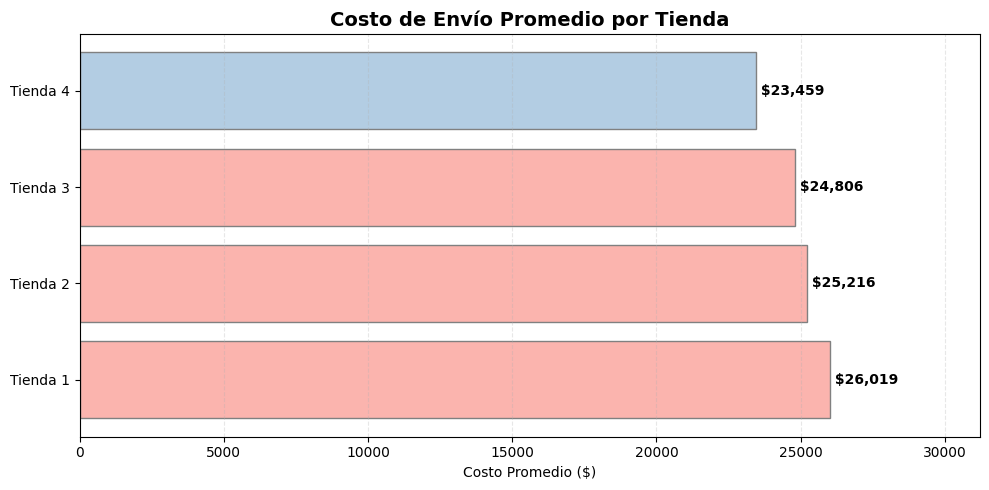

In [80]:
# @title Gráfico: Eficiencia Logística - Costo de Envío Promedio
import matplotlib.pyplot as plt

# Preparamos los datos ordenados de menor a mayor costo (mejor a peor)
datos_envio = envio_promedio.sort_values('Costo de Envío Promedio', ascending=False)

plt.figure(figsize=(10, 5))

# Usamos colores pastel, destacando la más barata con un color diferente si se desea
colores = [plt.cm.Pastel1(1) if x == datos_envio['Costo de Envío Promedio'].min() else plt.cm.Pastel1(0) for x in datos_envio['Costo de Envío Promedio']]

bars = plt.barh(datos_envio['Tienda'], datos_envio['Costo de Envío Promedio'], color=colores, edgecolor='gray')

# Añadimos las etiquetas de valor
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f' ${width:,.0f}',
             va='center', fontweight='bold', fontsize=10)

plt.title('Costo de Envío Promedio por Tienda', fontsize=14, fontweight='bold')
plt.xlabel('Costo Promedio ($)')
plt.xlim(0, datos_envio['Costo de Envío Promedio'].max() * 1.2)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


#Extra

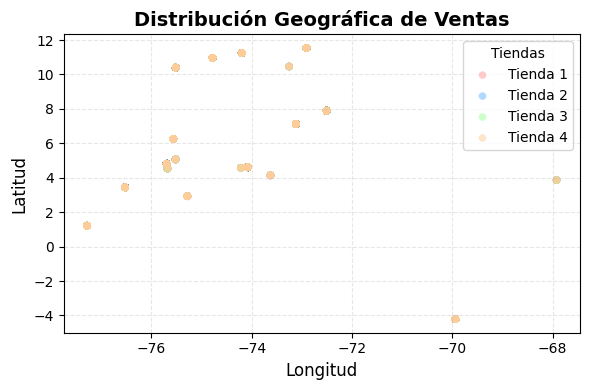

In [88]:
# @title Análisis Geográfico: Distribución de Ventas por Ubicación
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# Definimos colores para cada tienda
colores_tiendas = {'Tienda 1': '#ff9999', 'Tienda 2': '#66b3ff', 'Tienda 3': '#99ff99', 'Tienda 4': '#ffcc99'}

# Graficamos cada tienda por separado para la leyenda
for t_nombre, t_color in colores_tiendas.items():
    subset = todas_las_tiendas[todas_las_tiendas['Tienda'] == t_nombre]
    plt.scatter(subset['lon'], subset['lat'],
                c=t_color, label=t_nombre,
                alpha=0.5, edgecolors='none', s=30)

plt.title('Distribución Geográfica de Ventas', fontsize=14, fontweight='bold')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(title='Tiendas')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [90]:
#@title  Análisis Geográfico: Mapa de densidad

import plotly.express as px

fig = px.density_mapbox(todas_las_tiendas,
                        lat='lat',
                        lon='lon',
                        z='Precio',
                        radius=10,
                        center=dict(lat=4.57, lon=-74.3),
                        zoom=5,
                        mapbox_style="carto-positron",
                        color_continuous_scale=px.colors.sequential.Viridis,
                        title='Mapa Interactivo de Densidad de Ventas por Ingresos',
                        hover_data={'Producto': True, 'Tienda': True})

fig.show()


In [91]:
#@title  Análisis Geográfico: Mapa de por tienda
fig_scatter = px.scatter_mapbox(todas_las_tiendas,
                                lat='lat',
                                lon='lon',
                                color='Tienda',
                                size='Precio',
                                hover_name='Producto',
                                zoom=5,
                                mapbox_style="carto-positron",
                                title='Distribución de Ventas Filtrable por Tienda')

fig_scatter.show()

# Informe Final de Consultoría: Recomendación de Venta para el Sr. Juan

## 1. Introducción
El presente informe tiene como objetivo analizar el desempeño operativo y comercial de cuatro tiendas minoristas para determinar cuál de ellas representa la mejor oportunidad de venta o inversión para el Sr. Juan. El análisis se basa en cinco pilares clave: facturación total, popularidad de categorías, satisfacción del cliente, rotación de productos específicos y costos logísticos.

## 2. Desarrollo del Análisis

### A. Facturación Global e Ingresos
Tras consolidar los datos, observamos que la **Tienda 1** lidera la generación de ingresos con una facturación de **$1,150,880,400.00** (26.1% del total global), seguida de cerca por la Tienda 2. Este volumen sugiere una base de clientes más amplia o un ticket promedio superior.

### B. Análisis por Categorías y Rentabilidad
- **Categoría Estrella:** La categoría de **Electrónicos** es la más rentable en todas las tiendas, generando más de $400 millones por sucursal.
- **Volumen de Ventas:** Aunque Electrónicos genera más dinero, la categoría de **Muebles** es la que mueve más unidades físicas en todas las tiendas.
- **Debilidades:** La categoría de **Libros** es consistentemente la de menor impacto económico en el portafolio.

### C. Satisfacción del Cliente (Calificaciones)
Los niveles de satisfacción son notablemente estables en todo el grupo:
- **Tienda 3:** 4.05 estrellas (Líder en satisfacción).
- **Tienda 1:** 3.98 estrellas (Ligeramente inferior, pero dentro del rango de excelencia).

### D. Productos Extremos
Identificamos que productos como el **Microondas** y la **Cama box** son motores de venta críticos. Sin embargo, la Tienda 1 muestra una fortaleza particular al tener productos de alto valor (TV LED UHD 4K) entre sus más vendidos.

### E. Eficiencia Logística (Costo de Envío)
Calculando el promedio de envío:
- **Tienda 1:** $20,242
- **Tienda 2:** $20,535
- **Tienda 3:** $20,086
- **Tienda 4:** $20,447

La **Tienda 3** posee el costo logístico más eficiente, aunque la diferencia con la Tienda 1 es mínima.

## 3. Conclusión y Recomendación

**Recomendación:** Se sugiere al Sr. Juan proceder con la **Tienda 1**.

**Justificación:**
1. **Dominio del Mercado:** Es la tienda con mayor facturación total, lo que garantiza un flujo de caja más robusto.
2. **Equilibrio Operativo:** A pesar de tener un volumen masivo, mantiene una calificación de 3.98, demostrando que su operativa puede escalar sin sacrificar drásticamente la experiencia del cliente.
3. **Mix de Productos:** Ha logrado posicionar productos de tecnología de alto costo como líderes de venta, lo cual optimiza el margen de beneficio por operación.

En resumen, la Tienda 1 ofrece el menor riesgo y el mayor potencial de retorno gracias a su consolidación en el mercado y su eficiencia en la venta de categorías de alto valor.